# Drug_Classification using SVM

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, Seaborn, and SKLearn libraries.
- Our primary focus will be on key operations commonly used in these libraries for building Linear Regression models.
- The following operations will be conducted on the CSV file:

   - Importing the necessary libraries.
   - Loading the dataset for the experiment.
   - Understanding the data contained in the file.
   - Performing data cleaning.
   - Preparing the data for further processing within the Data Science Life Cycle.
   - Conducting Exploratory Data Analysis (EDA) on the processed data.
   - Building predictive models using the EDA-processed data.
   - Performing model evaluations.

**Experiment Link** --> https://colab.research.google.com/drive/10QT7XeML6TIMFUzBQO55tfoNW513Jy-8?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/1atwp244ueBmYbp8ryMJtrZamiM_JvdJF/view?usp=sharing

### STEP 1. Problem statement:-
- Here, we want to classify the drug for a patient to use to control cholesterol based on their current health data.

### STEP 2.Importing the necessary libraries.

In [ ]:
# Import Libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 3.Loading the Dataset into the Environment.


In [ ]:
# Loading the dataset.
df = pd.read_csv("/content/drug.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [ ]:
# Understanding the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [ ]:
df.shape

(200, 6)

### STEP 4.Data Cleaning Operation performed om the dataset.


In [ ]:
# checking for null values.
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [ ]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Checking for the unique values in the target column.
df['Drug'].unique()

array(['DrugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

In [ ]:
# Checking the value count of the target column.
df['Drug'].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


### STEP 5.Feature Engineering for Encoding, Scaling, and Feature Creation.


In [ ]:
#labelencoding
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Applying Label Encoding on the object columns.
le = LabelEncoder()
for i in df.columns:
  if df[i].dtype == "object":
    df[i] = le.fit_transform(df[i])

In [ ]:
df.dtypes

,0
Age,int64
Sex,int64
BP,int64
Cholesterol,int64
Na_to_K,float64
Drug,int64


- Now, all columns with the object data type have been converted into numeric data type columns.

### STEP 6. Divide the dataset into features (x) and the target variable (y) for training the model.

In [ ]:
x = df.drop("Drug", axis = 1)
y = df['Drug']

In [ ]:
x.shape

(200, 5)

In [ ]:
y.shape

(200,)

In [ ]:
#train-test-split
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.5,random_state =0)

### STEP 7.Model Selection & Training:

- Model - 1 (RBF)

In [ ]:
#svc  --- bydefault - rbf
from sklearn.svm import SVC
model = SVC()

In [ ]:
#training
model.fit(x_train,y_train)

SVC()

In [ ]:
# Predicting the values with test data.
y_pred = model.predict(x_test)

- Model - 2 (Linear)

In [ ]:
#svc  --- linear
from sklearn.svm import SVC
model = SVC(kernel = "linear")

In [ ]:
#training
model.fit(x_train,y_train)

SVC(kernel='linear')

In [ ]:
# Predicting the values with test data.
y_pred = model.predict(x_test)

- Model - 3 (Polynomial)

In [ ]:
#svc  ---poly
from sklearn.svm import SVC
model = SVC(kernel = "poly")

In [ ]:
#training
model.fit(x_train,y_train)

SVC(kernel='poly')

In [ ]:
# Predicting the values with test data.
y_pred = model.predict(x_test)

### STEP 8: Model Evaluation  
- Model -1

In [ ]:
# Import evaluation
from sklearn.metrics import*
print(accuracy_score(y_test,y_pred)*100)

72.0


- Model -2

In [ ]:
# Import evaluation
print(accuracy_score(y_test,y_pred)*100)

98.0


- Model -3

In [ ]:
# Import evaluation
print(accuracy_score(y_test,y_pred)*100)

68.0


# Visualising three models with Line and Bar plots based on there accuracys.

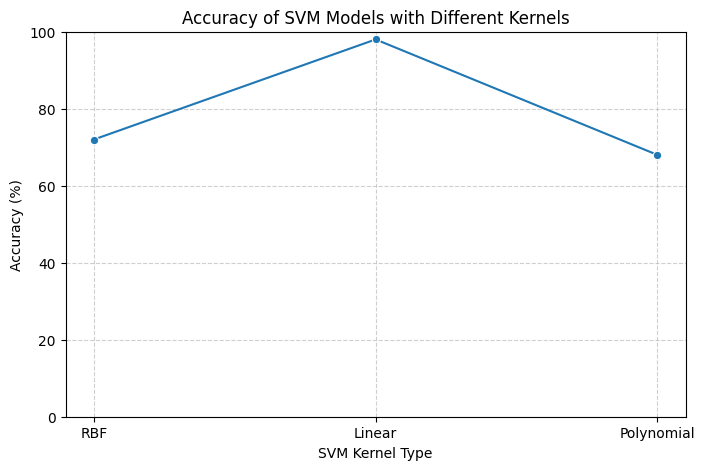

In [ ]:
model_names = ['RBF', 'Linear', 'Polynomial']
accuracy_scores = [72.0, 98.0, 68.0]

plt.figure(figsize=(8, 5))
sns.lineplot(x=model_names, y=accuracy_scores, marker='o')
plt.title('Accuracy of SVM Models with Different Kernels')
plt.xlabel('SVM Kernel Type')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Set y-axis limit from 0 to 100
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

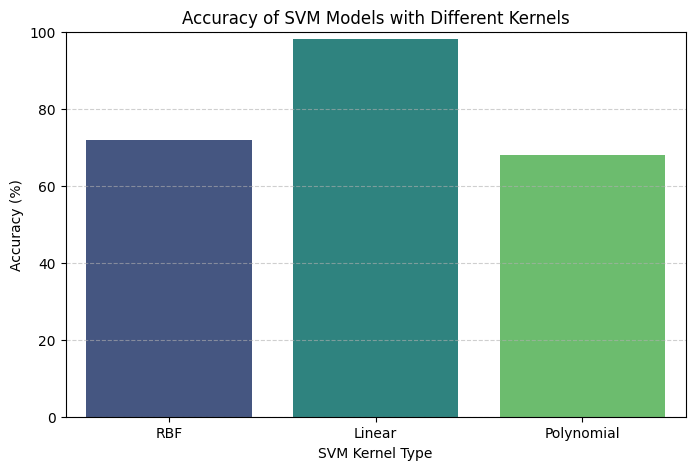

In [ ]:
model_names = ['RBF', 'Linear', 'Polynomial']
accuracy_scores = [72.0, 98.0, 68.0]

plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracy_scores, palette='viridis', hue=model_names, legend=False)
plt.title('Accuracy of SVM Models with Different Kernels')
plt.xlabel('SVM Kernel Type')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Set y-axis limit from 0 to 100
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

- After building the three models, we evaluated them and achieved " 98 % accuracy " in the kernel = Linear Model.
